## 2D spectrum

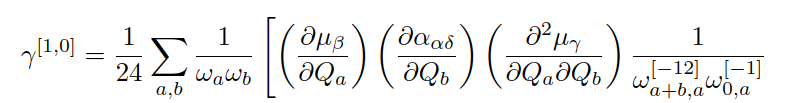

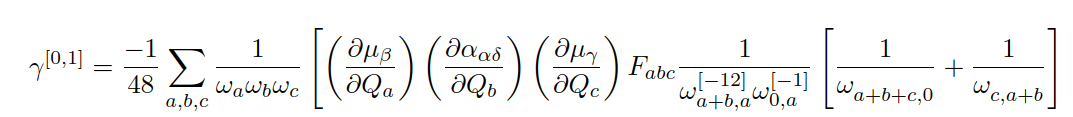

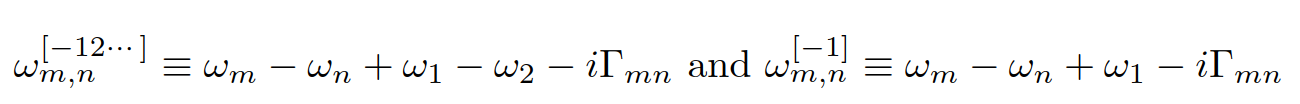

1. Input data for derivs (structure)
2. Orientational averiging
3. Countour plots for spectrum
4. Realistic values of freqs

### VeloxChem calculations

In [ ]:
import veloxchem as vlx
import numpy as np
import sys
# import py3Dmol as p3d
from veloxchem.veloxchemlib import bohr_in_angstroms

# Define the molecule and basis set
molecule_string = """3

  O 0.000 0.000  0.000
  H 0.000 0.000  0.950
  H 0.896 0.000 -0.317"""
basis_set_label = 'sto-3g'

molecule = vlx.Molecule.from_xyz_string(molecule_string)
basis = vlx.MolecularBasis.read(molecule, basis_set_label)

# Run the SCF calculation
scf_settings = {}
method_settings = {} #{'xcfun':'b3lyp'}
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.update_settings(scf_settings, method_settings)
scf_results = scf_drv.compute(molecule, basis)

# Create the Hessian Driver and use it to compute an analytical SCF Hessian
hessian_settings = {}
hessian_drv = vlx.scfhessiandriver.ScfHessianDriver(scf_drv)
hessian_drv.update_settings(method_settings, hessian_settings)
hessian_drv.compute(molecule, basis)

hessian_drv.vibrational_analysis(molecule)

In [ ]:
help(hessian_drv)

In [ ]:
freqs,ints = hessian_drv.frequencies, hessian_drv.ir_intensities
nmodes = hessian_drv.normal_modes
print(freqs)
# print()

## 2D-IR intensities

In [1]:
# one term function with given pattern of derivatives
def avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha):
    f = dmu[len(todo[0])-1][(beta,) + todo[0]]
    s = dalpha[len(todo[1])-1][(alpha, delta,) + todo[1]]
    t = dmu[len(todo[2])-1][(gamma,) + todo[2]]

    return f * s * t

# average over given suscept_tensor_comp
def orientavr(suscept_tensor_comp, todo, dmu, dalpha):
    ders_avrg = []
    
    for alpha in suscept_tensor_comp[0]:
        for beta in suscept_tensor_comp[1]:
            for gamma in suscept_tensor_comp[2]:
                for delta in suscept_tensor_comp[3]:
                    
                    ders_avrg.append(avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha))
                    
    avrgders = sum(ders_avrg) / len(ders_avrg)
    return avrgders

# dmu = [deriv_mu_first, deriv_mu_second]
# dalpha = [deriv_alpha_first, deriv_alpha_second]

# todo = [(2,), (1,), (2, 1,)]
# avrgterm(todo, 2, 2, 2, 2)
# orientavr([(2,), (2,), (2,), (2,)], todo)

In [81]:
# w1, w1-w2
import math
import numpy as np


# electrical anharmonicity
# @np.vectorize
def el_anhALLab(data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    # w1mw2 = w1-w2
    w_0 = 0
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
        
    for a in range(len(w)):
        for b in range(len(w)):
            firstfrac = 1/ w[a] / w[b]
            
            # term 1 --------------------------
            resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
            resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
                    
            todo1 = [(a,), (b,), (a, b,)]
            avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
            # avrgders = 1
            
            term1 = avrgders / resonance1_1 / resonance2_1
            
            if t2:
                # term 2 --------------------------
                resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
                resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

                todo2 = [(a,), (a, b,), (b,)]
                avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                # avrgders2 = 1
                
                term2 = avrgders2 / resonance1_2 / resonance2_2
            else:
                term2 = 0
            
            totalres += firstfrac * (term1+ term2)
            # print(firstfrac * (term1+ term2), (firstfrac * (term1 + term2)).shape)
            
    return totalres/24. #* 10**5


def el_anh_ab(a, b, data, settings):
    """
    """
    t2 = settings['el_t2']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    firstfrac = 1/ w[a] / w[b]
    
    # term 1 --------------------------
    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] + (w1-w2) - Gamma * 1j
    resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
    
    # averaging
    todo1 = [(a,), (b,), (a, b,)]
    avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
    avrgders = 1
    
    term1 = avrgders / resonance1_1 / resonance2_1
    
    if t2:
        # term 2 --------------------------
        resonance1_2 = w[b] - w[a] + (w1-w2) - Gamma * 1j
        resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j

        # averaging
        todo2 = [(a,), (a, b,), (b,)]
        avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
        avrgders2 = 1

        term2 = avrgders2 / resonance1_2 / resonance2_2
    else:
        term2 = 0
            
    totalres += firstfrac * (term1+term2)
    
    return totalres/24. #* 10**5


def mech_anh(data, settings):
    on = settings['mech_on']
    t2 = settings['mech_t2']
    t3 = settings['mech_t3']
    
    w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = data
    w1mw2 = w1-w2
    w_0 = 0
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    # totalres = []
    
    if not on:
        return totalres
    
    else:
    
        for a in range(len(w)):
            for b in range(len(w)):
                for c in range(len(w)):

                    firstfrac = 1 / w[a] / w[b] / w[c]

                    # term 1 -------------------------- 
                    fracs = 1 / ((w[a] + w[b] + w[c] - Delta['abc']) - w_0) + 1 / (w[c] - (w[a] + w[b] - Delta['ab']))

                    resonance1_1 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                    resonance2_1 = w_0 - w[a] - Gamma * 1j

                    # averaging
                    todo1 = [(a,), (b,), (c,)]
                    avrgders = orientavr(suscept_tensor_comps, todo1, deriv_mu, deriv_alpha)
                    avrgders = 1
                    
                    term1 = avrgders * fracs * F[a, b, c] / resonance1_1 / resonance2_1

                    if t2:
                        # term 2 -------------------------- 
                        fracs2 = 1 / ((w[a] + w[b] - Delta['ab']) - w[c]) + 1 / ((w[b] + w[c] - Delta['bc']) - w[a])

                        resonance1_2 = w[c] - w[a] - w1mw2 - Gamma * 1j
                        resonance2_2 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo2 = [(a,), (b,), (c,)]
                        avrgders2 = orientavr(suscept_tensor_comps, todo2, deriv_mu, deriv_alpha)
                        avrgders2 = 1
                        
                        term2 = avrgders2 * fracs2 * F[a, b, c] / resonance1_2 / resonance2_2
                    else:
                        term2 = 0

                    if t3:
                        # term 3 -------------------------- 
                        fracs3 = 1 / (w[a] - (w[a] + w[b] - Delta['ab'])) + 1 / (w[b] - w_0)

                        resonance1_3 = (w[a] + w[b] - Delta['ab']) - w[a] - w1mw2 - Gamma * 1j
                        resonance2_3 = w_0 - w[a] - Gamma * 1j

                        # averaging
                        todo3 = [(a,), (b,), (a,)]
                        avrgders3 = orientavr(suscept_tensor_comps, todo3, deriv_mu, deriv_alpha)
                        avrgders3 = 1

                        term3 = avrgders3 * fracs3 * F[a, b, c] / resonance1_3 / resonance2_3
                    else:
                        term3 = 0

                    totalres += firstfrac * (term1 + term2 + term3)
                    # totalres.append(firstfrac * (term1 + term2 + term3))

        return -totalres/48. #* 10**5


def spectrum(data, settings):
    w1mw2=settings['w1mw2_axis']
    prt=settings['printing']
    # compute the third dimension at each point on the grid
    ELanh = el_anhALLab(data, settings)
    MECHanh = mech_anh(data, settings)
    Z = abs(ELanh + MECHanh)**2
    
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None
        
    return data[0], data[1], Z


%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

def plotspectrum(ranges, numbers, settings):
    # ALL PARAMETERS 
    w1_s, w1_e, w2_s, w2_e, Nfreqs = ranges
    w1, w2 = np.linspace(w1_s, w1_e, Nfreqs), np.linspace(w2_s, w2_e, Nfreqs)
    
    w1mw2=settings['w1mw2_axis']
    # w1, w2, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F = numbers
    
    xx, yy = np.meshgrid(w1, w2)
    numbers[0], numbers[1] = xx, yy
    
    # PLOTTING
    fig, ax = plt.subplots()
    fig.set_size_inches(11, 9)

    X, Y, Z = spectrum(numbers, settings)
    Z = Z#*10**18
    
    # print(numbers)
    xaxis = X
    ax.set_xlabel('w1', fontsize=18)

    if w1mw2:
        yaxis = X-Y
        ax.set_ylabel('w1-w2', fontsize=18)
    else:
        yaxis = Y
        ax.set_ylabel('w2', fontsize=18)
    
    cp = ax.contourf(xaxis, yaxis, Z)

    # ax.legend()

    cb = plt.colorbar(cp)
    # plt.grid()
    fig.set_tight_layout(True)

    ax.set_xticks(np.linspace(min(xaxis.flatten())-10, max(xaxis.flatten())+10, 25))
    ax.set_yticks(np.linspace(min(yaxis.flatten())-10, max(yaxis.flatten())+10, 25))

    ax.set_xlim(min(xaxis.flatten())-20, max(xaxis.flatten())+20)
    ax.set_ylim(min(yaxis.flatten())-20, max(yaxis.flatten())+20)

    plt.xticks(rotation = 90)
    
    if not w1mw2:
        for k, f in w.items():
            plt.axvline(x=f, color ='k', linewidth=1)
            plt.axhline(y=f, color ='k', linewidth=1)
    
    plt.show()

In [82]:
# DERIVATIVES SETUP

# deriv_mu_first[0, i] --- delta(mu_x)/delta(Q_i)
# deriv_mu_first[1, i] --- delta(mu_y)/delta(Q_i)
deriv_mu_first = np.array([14.1]*3*3).reshape(3, 3)

# deriv_mu_second[0, i, j] --- delta(mu_x)/delta(Q_i)/delta(Q_j)
# deriv_mu_second[1, i, j] --- delta(mu_y)/delta(Q_i)/delta(Q_j)
deriv_mu_second = np.array([22.1]*3*3*3).reshape(3, 3, 3)

deriv_mu = [deriv_mu_first, deriv_mu_second]

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
deriv_alpha_first = np.array([-7.1]*3*3*3).reshape(3, 3, 3)

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
# deriv_alpha_second[0, 1, i, j] --- delta(alpha_xy)/delta(Q_i)/delta(Q_j)
deriv_alpha_second = np.array([13.1]*3*3*3*3).reshape(3, 3, 3, 3)

deriv_alpha = [deriv_alpha_first, deriv_alpha_second]

suscept_tensor_comps = [[2], [2], [2], [2]]

Gamma = 0.0001
Delta = {'aa': 70, 'bb': 50, 'ab': 70, 'bc': 50, 'abc': 90}

w = {0: 1927.08382347, 1: 4545.77721188, 2: 4896.43798171}

F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 170.24

w2_s = 800
w2_e = 5590
w1_s = w2_s-700
w1_e = w2_e-700
Nfreqs = 50

ranges = (w1_s, w1_e, w2_s, w2_e, Nfreqs)
data = [[], [], w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F] 

# settings = {'el_t2':True, 'mech_on':True, 'mech_t2':False, 'mech_t3':False, 'w1mw2_axis': False, 'printing': False}

# plotspectrum(ranges, data, settings)

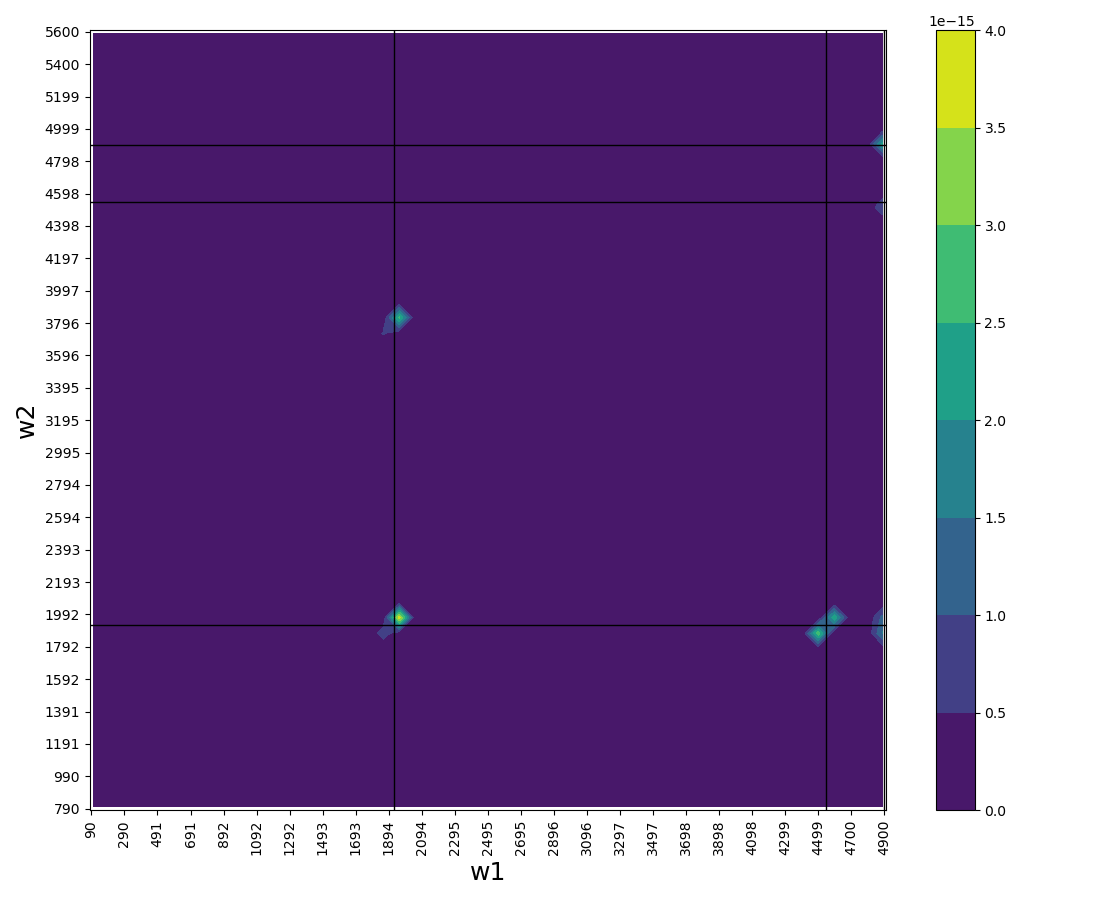

In [83]:
settings = {'el_t2':True, 'mech_on':True, 'mech_t2':False, 'mech_t3':False, 'w1mw2_axis': False, 'printing': False}

plotspectrum(ranges, data, settings)

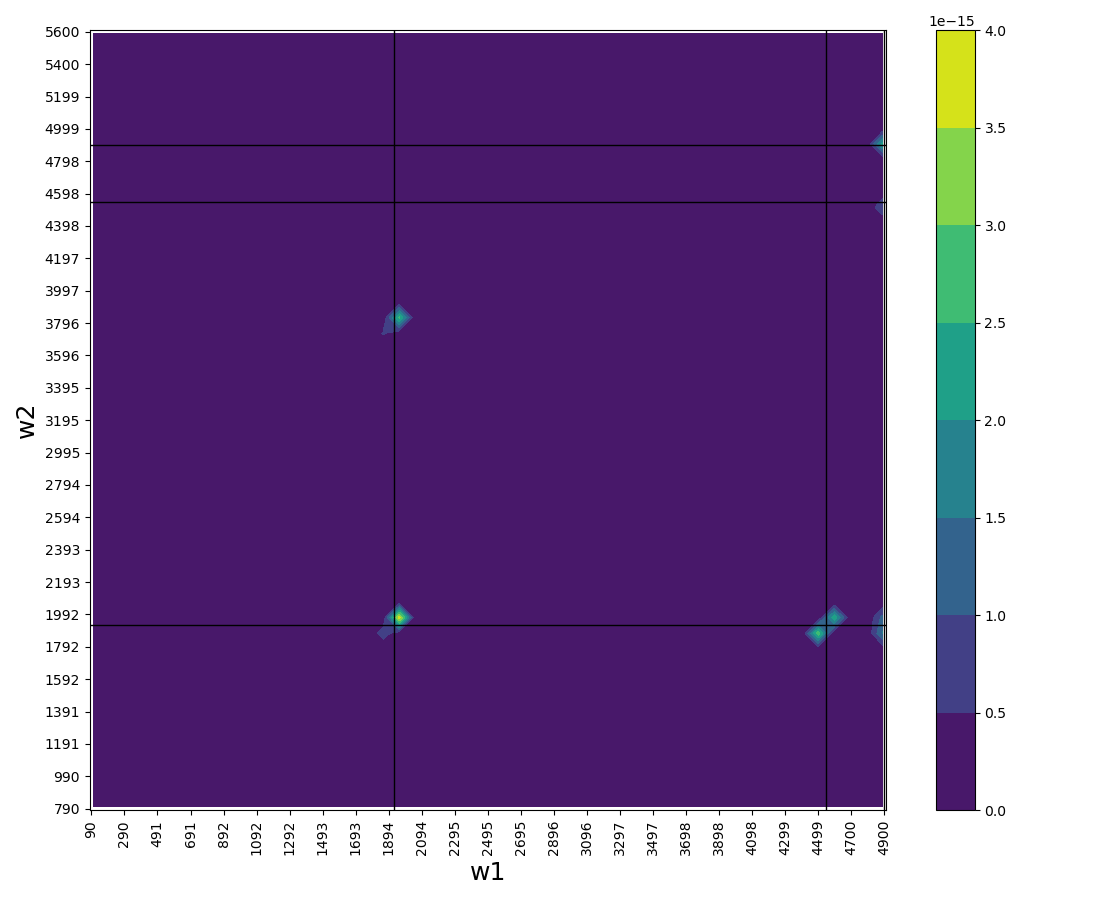

In [74]:
settings = {'el_t2':True, 'mech_on':True, 'mech_t2':True, 'mech_t3':False, 'w1mw2_axis': False, 'printing': False}

plotspectrum(ranges, data, settings)

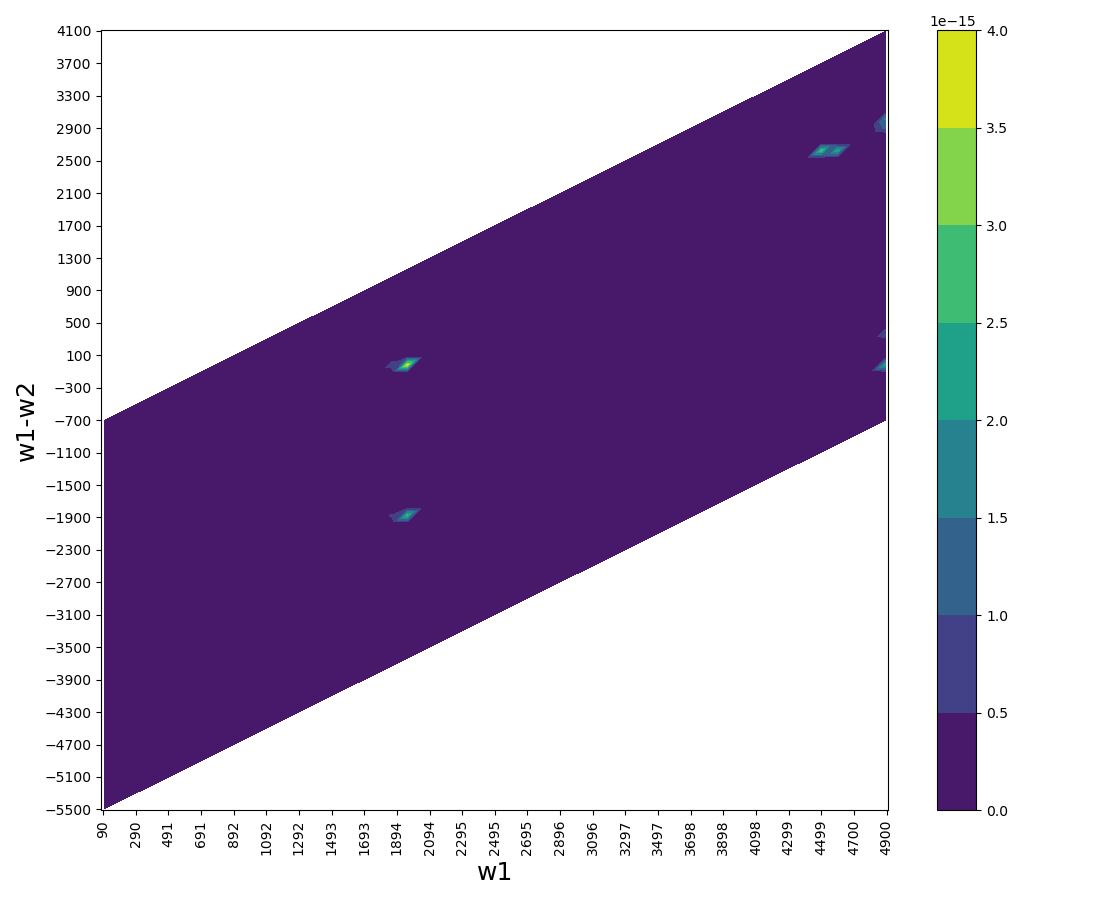

In [79]:
settings = {'el_t2':True, 
            'mech_on':False, 'mech_t2':True, 'mech_t3':False, 
            'w1mw2_axis': True, 'printing': False}

plotspectrum(ranges, data, settings)

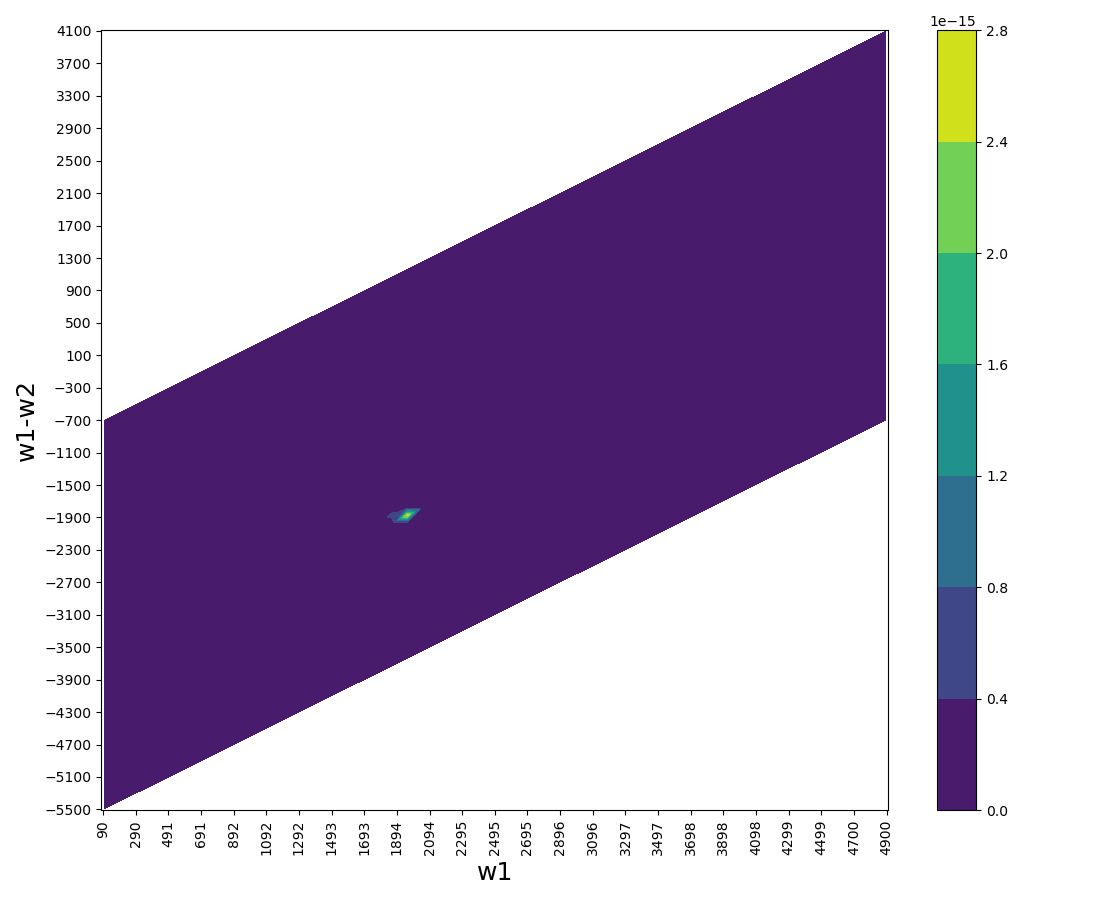

In [78]:
settings = {'el_t2':False, 
            'mech_on':False, 'mech_t2':True, 'mech_t3':False, 
            'w1mw2_axis': True, 'printing': False}

plotspectrum(ranges, data, settings)

In [ ]:
def testgrid(x, y, a):
    return x+y+a#+(x-y)
def testgrid2(x, y, a):
    print('-----')
    print(x-y)
    print('-----')
    return x+y+a+(x-y)
x = np.array([1, 2, 3])
y = np.array([1, 2, 3])
xx, yy = np.meshgrid(x, y)
print(xx)
print(yy)

print('\n')
print(testgrid(x, y, 10))

print('\n')
print(testgrid(xx, yy, 10))

print('\n')
print(testgrid2(xx, yy, 10))

In [ ]:
w1 = np.array([1997., 4355., 4900.])
w2 = np.array([1997., 4355., 4900.])
w1, w2 = np.linspace(1500, 4990, 90), np.linspace(1500, 4990, 90)
xx, yy = np.meshgrid(w1, w2)

# xx, yy = np.array([1597.]), np.array([1697.])

numbers = [xx, yy, w, deriv_mu, deriv_alpha, Gamma, Delta, suscept_tensor_comps, F]
z = abs(el_anhALLab(numbers, t2=False) )**2 #+ mech_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, F, w, Delta))**2 * 10**25
# np.set_printoptions(suppress=True)
print(z)

In [ ]:
# w2 = np.array([ 2, 3, 5])
# w1 = np.array([ 2, 3, 5])

# w = {0: 1,
#      1: 4, 
#      2: 6}

# F = np.zeros((len(w), len(w), len(w)))
# F[0, 1, 2] = 0.01

# %matplotlib widget
# # spectrum(w1, w2, w, F, option1=False, prt=True)
# # spectrum(w1, w2, w, F, option1=True)

In [ ]:
lines = {}
        
def update(Fabc
          # , nu0, nu1, nu2, delta_ab
          ):
    global cb
    F[0, 1, 2] = Fabc
    # w[0] = nu0
    # w[1] = nu1
    # w[2] = nu2
    
    Xp, Yp, Zp = spectrum(w1, w2, w, F, delta_ab, option1=option1, prt=False)

    # sc = ax.scatter(Xp.flatten(), Yp.flatten(), c=Zp.flatten(), cmap='viridis'
    #                 #, s=20
    #                )
    
    cp = ax.contour(Xp, Yp, Zp)
    
    # sc.set_offsets(np.c_[Xp,Yp])
    # sc.set_array(Zp.flatten()) 

    # for text in ax.texts:
    #     if text.get_text() != '':  # only remove ax.text objects
    #         text.remove()
            
    # for i in range(len(w1)):
    #     for j in range(len(w2)):
    #         ax.text(Xp[i, j]-0.2, Yp[i, j]+0.3, 
    #                 f'{Zp[i, j]:.3f}',
    #                 #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
    #                 ha='right', va='bottom')
    
    color = iter(cm.rainbow(np.linspace(0, 1, len(w)))) 
    # for i in w:
    
    if not lines == {}:
        for i, c in zip(range(len(w)), color):
        
            # print(lines)
            lines.pop(i).remove()
            lines.pop(i+10).remove()
    
    for i, c in zip(range(len(w)), color):
        # color = next(color)
        # print(lines, 'hdkweh')

        lines[i] = ax.axhline(y=w[i], color=c, linestyle='-', label=f'w_{i}')
        lines[i+10] = ax.axvline(x=w[i], color=c, linestyle='-', label=f'w_{i}')
        # print(lines, 'after')

        # ax.text(w[i]-0.2, -0.5, 
        #             f'w_{i}',
        #             #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
        #             ha='right', va='bottom')
        
    # print(list(ax.lines))
    # print(lines)
    cb.remove()   # FIX updating colorbar
    cb = plt.colorbar(cp)
    fig.canvas.draw_idle()

    # print(Z)

# Fabc_slider = FloatSlider(min=0.1, max=6, step=0.1, value=0.1)
# nu0_slider = FloatSlider(min=1, max=5, step=0.5, value=2)
# nu1_slider = FloatSlider(min=4, max=9, step=0.5, value=6)
# nu2_slider = FloatSlider(min=9, max=13, step=0.5, value=10)

# delta_ab_slider = FloatSlider(min=50., max=200., step=10, value=50.0)

# interact(update, Fabc=Fabc_slider, 
#          #nu0=nu0_slider, nu1=nu1_slider, nu2=nu2_slider, delta_ab=delta_ab_slider, 
#          sc=sc) # FIX sc thing
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6,5))
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes([left, bottom, width, height]) 

start, stop, n_values = -8, 8, 800

x_vals = np.linspace(start, stop, n_values)
y_vals = np.linspace(start, stop, n_values)
X, Y = np.meshgrid(x_vals, y_vals)


Z = np.sqrt(X**2 + Y**2)

cp = plt.contourf(X, Y, Z)
plt.colorbar(cp)

ax.set_title('Contour Plot')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# generate some initial data
x = np.random.rand(10)
y = np.random.rand(10)
colors = np.random.rand(10)

# create a scatter plot of the data
fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=colors)

# define a function to update the data
def update_data():
    new_x = np.random.rand(10)
    new_y = np.random.rand(10)
    new_colors = np.random.rand(10)
    sc.set_offsets(np.c_[new_x, new_y])
    sc.set_array(new_colors)
    fig.canvas.draw()

# connect the function to a button click event
button_ax = fig.add_axes([0.8, 0.1, 0.1, 0.05])
button = plt.Button(button_ax, 'Update')
button.on_clicked(lambda event: update_data())

# show the plot
plt.show()


### Saved images

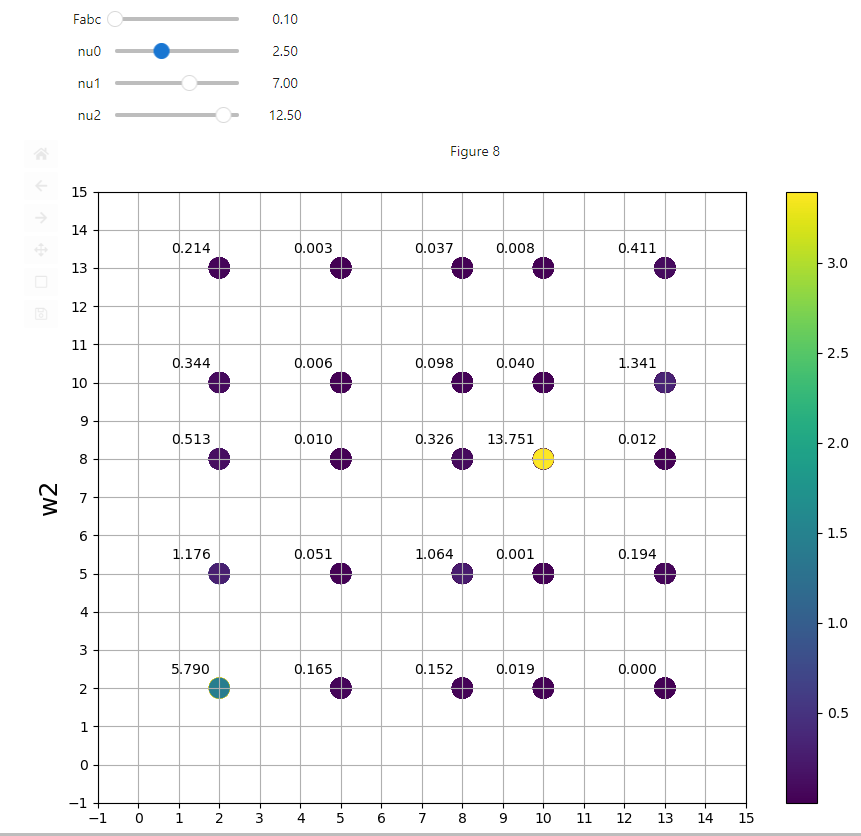

-----
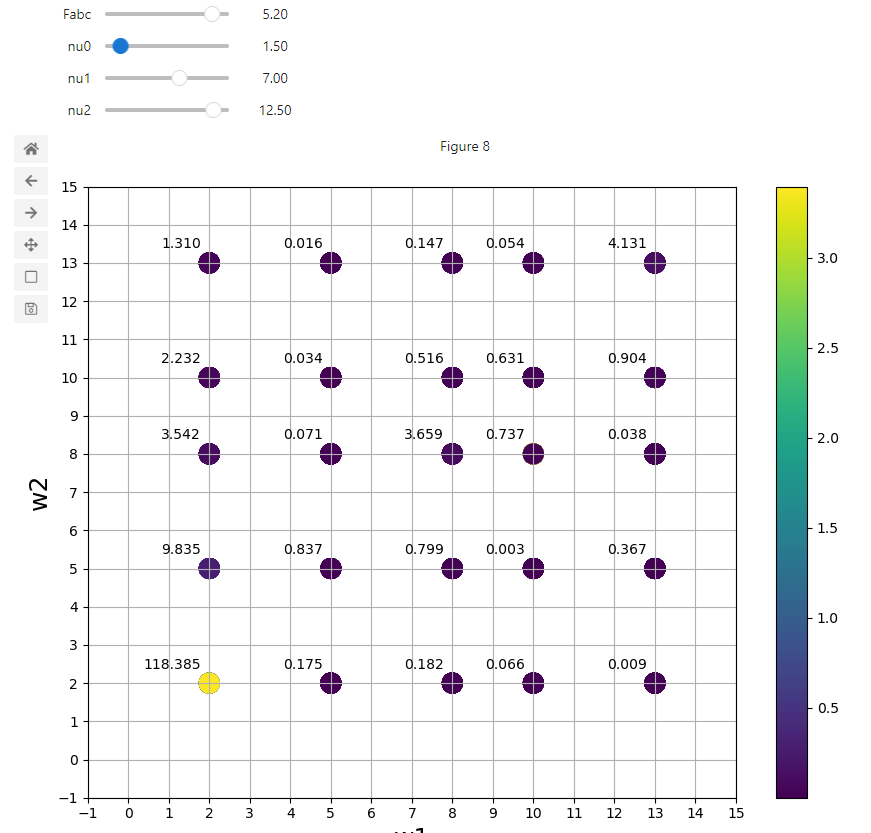